# Router Pattern (라우터 패턴)

**라우터 패턴(Router Pattern)** 은 라우팅 단계에서 입력을 분류하고, 전문 에이전트로 라우팅하며,
결과를 통합하여 결합된 응답을 생성하는 멀티 에이전트 아키텍처입니다.

이 패턴은 조직의 지식이 서로 다른 **수직 영역(verticals)** 에 분산되어 있을 때 특히 효과적입니다.
각 영역은 고유한 도구와 프롬프트를 가진 전문 에이전트가 필요합니다.

이 튜토리얼에서는 GitHub, Notion, Slack 세 가지 지식 소스를 통합하는 라우터를 구축합니다.

**참고**: [LangChain 공식 문서 - Router Knowledge Base](https://docs.langchain.com/oss/python/langchain/multi-agent/router-knowledge-base)

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [2]:
from langchain.chat_models import init_chat_model

# 메인 모델과 라우터용 경량 모델
model = init_chat_model("gpt-5-mini", model_provider="openai")
router_llm = init_chat_model("gpt-5.4-mini", model_provider="openai")  # 라우터는 경량 모델 사용 가능

## 1. 상태 정의

라우터의 상태를 정의합니다.

In [3]:
from typing import TypedDict, Annotated, Literal
import operator

# 각 에이전트 노드에 전달되는 입력 (Send로 전달되는 상태)
class AgentInput(TypedDict):
    """각 하위 에이전트 노드의 입력"""
    query: str

# 분류 결과
class Classification(TypedDict):
    """라우팅 결정: 어떤 에이전트를 어떤 쿼리로 호출할지"""
    source: Literal["github", "notion", "slack"]
    query: str

# 에이전트 출력
class AgentOutput(TypedDict):
    """각 하위 에이전트의 출력"""
    source: str
    result: str

# 라우터 상태 (results는 reducer로 병렬 결과 수집)
class RouterState(TypedDict):
    """라우터의 전체 상태"""
    query: str
    classifications: list[Classification]
    results: Annotated[list[AgentOutput], operator.add]
    final_answer: str

## 2. 도구 정의

각 지식 소스별로 도구를 정의합니다.

In [4]:
from langchain.tools import tool

# GitHub 도구
@tool
def search_code(query: str, repo: str = "main") -> str:
    """GitHub 저장소에서 코드를 검색합니다."""
    return f"코드 검색 결과 '{query}' in {repo}: src/auth.py의 인증 미들웨어"

@tool
def search_issues(query: str) -> str:
    """GitHub 이슈와 풀 리퀘스트를 검색합니다."""
    return f"'{query}'와 일치하는 이슈 3개 발견: #142 (API 인증 문서), #89 (OAuth 플로우), #203 (토큰 갱신)"

@tool
def search_prs(query: str) -> str:
    """구현 세부사항을 위해 풀 리퀘스트를 검색합니다."""
    return f"PR #156에서 JWT 인증 추가, PR #178에서 OAuth 스코프 업데이트"

# Notion 도구
@tool
def search_notion(query: str) -> str:
    """Notion 워크스페이스에서 문서를 검색합니다."""
    return f"문서 발견: 'API 인증 가이드' - OAuth2 플로우, API 키, JWT 토큰 다룸"

@tool
def get_page(page_id: str) -> str:
    """특정 Notion 페이지를 ID로 가져옵니다."""
    return f"페이지 내용: 단계별 인증 설정 지침"

# Slack 도구
@tool
def search_slack(query: str) -> str:
    """Slack 메시지와 스레드를 검색합니다."""
    return f"#engineering 채널에서 토론 발견: 'API 인증에는 Bearer 토큰 사용, 갱신 플로우는 문서 참조'"

@tool
def get_thread(thread_id: str) -> str:
    """특정 Slack 스레드를 가져옵니다."""
    return f"스레드에서 API 키 로테이션 모범 사례 논의"

C:\Users\trimu\anaconda3\envs\langchain\Lib\site-packages\langgraph\checkpoint\base\__init__.py:17: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## 3. 전문 에이전트 생성

각 지식 소스별로 전문 에이전트를 생성합니다.

In [5]:
from langchain.agents import create_agent

# GitHub 에이전트
github_agent = create_agent(
    model,
    tools=[search_code, search_issues, search_prs],
    system_prompt=(
        "당신은 GitHub 전문가입니다. "
        "코드, API 참조, 구현 세부사항에 대한 질문에 답변하기 위해 "
        "저장소, 이슈, 풀 리퀘스트를 검색하세요."
    ),
)

# Notion 에이전트
notion_agent = create_agent(
    model,
    tools=[search_notion, get_page],
    system_prompt=(
        "당신은 Notion 전문가입니다. "
        "내부 프로세스, 정책, 팀 문서에 대한 질문에 답변하기 위해 "
        "조직의 Notion 워크스페이스를 검색하세요."
    ),
)

# Slack 에이전트
slack_agent = create_agent(
    model,
    tools=[search_slack, get_thread],
    system_prompt=(
        "당신은 Slack 전문가입니다. "
        "관련 스레드와 토론을 검색하여 팀원들이 공유한 지식과 해결책을 찾아 답변하세요."
    ),
)

## 4. 쿼리 분류

사용자 쿼리를 분석하여 어떤 에이전트를 호출할지 결정합니다.

In [6]:
from pydantic import BaseModel, Field

# 구조화된 출력 스키마
class ClassificationResult(BaseModel):
    """쿼리 분류 결과"""
    classifications: list[Classification] = Field(
        description="호출할 에이전트와 타겟팅된 하위 질문 목록"
    )

def classify_query(state: RouterState) -> dict:
    """쿼리를 분류하고 어떤 에이전트를 호출할지 결정합니다."""
    structured_llm = router_llm.with_structured_output(ClassificationResult)
    
    system_prompt = """이 쿼리를 분석하고 어떤 지식 베이스를 참조할지 결정하세요.
각 관련 소스에 대해 해당 소스에 최적화된 타겟팅된 하위 질문을 생성하세요.

사용 가능한 소스:
- github: 코드, API 참조, 구현 세부사항, 이슈, 풀 리퀘스트
- notion: 내부 문서, 프로세스, 정책, 팀 위키
- slack: 팀 토론, 비공식 지식 공유, 최근 대화

쿼리와 관련된 소스만 반환하세요."""
    
    result = structured_llm.invoke([
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": state["query"]}
    ])
    
    return {"classifications": result.classifications}

## 5. 라우팅 및 에이전트 노드 (병렬 실행)

route_to_agents는 Send 목록을 반환하여 선택된 에이전트들을 병렬로 실행합니다.
각 에이전트 노드는 AgentInput을 받아 결과만 반환합니다.

In [7]:
from langchain_core.messages import HumanMessage
from langgraph.types import Send

# 병렬 분기 생성
def route_to_agents(state: RouterState) -> list:
    """
    분류 결과(classifications)에 따라
    각 전문 에이전트 노드로 Send 객체를 반환합니다.

    반환값:
        list[Send]
        → LangGraph가 해당 노드들을 병렬로 실행합니다.

    예:
        state["classifications"] = [
            {"source": "github", "query": "..."},
            {"source": "notion", "query": "..."}
        ]

        반환:
            [
                Send("github", {"query": "..."}),
                Send("notion", {"query": "..."})
            ]
    """

    return [
        # Send(노드 이름, 해당 노드에 전달할 상태)
        Send(c["source"], {"query": c["query"]})
        for c in state["classifications"]
    ]


# ------------------------------------------------------------
# GitHub 에이전트 호출 노드
# ------------------------------------------------------------
# 이 함수는 Graph의 "github" 노드에 해당합니다.
# AgentInput 형태의 state를 입력받아 GitHub 전문 에이전트를 실행합니다.
def query_github(state: AgentInput) -> dict:
    """
    GitHub 에이전트를 호출하여
    코드, 이슈, PR 관련 정보를 조회합니다.

    입력:
        state: {"query": "..."}  (AgentInput)

    출력:
        {"results": [{"source": "github", "result": "..."}]}
        → reducer(operator.add)에 의해 RouterState.results에 누적됨
    """

    # GitHub 전문 Agent 실행
    result = github_agent.invoke({
        "messages": [
            {"role": "user", "content": state["query"]}
        ]
    })

    last = result["messages"][-1]
    text = getattr(last, "content", None) or getattr(last, "text", str(last))

    # 결과를 RouterState.results에 추가할 형식으로 반환
    return {
        "results": [
            {
                "source": "github",  # 출처 명시
                "result": text       # 에이전트 응답 텍스트
            }
        ]
    }


# ------------------------------------------------------------
# Notion 에이전트 호출 노드
# ------------------------------------------------------------
def query_notion(state: AgentInput) -> dict:
    """
    Notion 에이전트를 호출하여
    내부 문서, 정책, 위키 정보를 조회합니다.
    """

    result = notion_agent.invoke({
        "messages": [
            {"role": "user", "content": state["query"]}
        ]
    })

    last = result["messages"][-1]
    text = getattr(last, "content", None) or getattr(last, "text", str(last))

    return {
        "results": [
            {
                "source": "notion",
                "result": text
            }
        ]
    }


# ------------------------------------------------------------
# Slack 에이전트 호출 노드
# ------------------------------------------------------------
def query_slack(state: AgentInput) -> dict:
    """
    Slack 에이전트를 호출하여
    팀 대화 및 스레드에서 관련 정보를 검색합니다.
    """

    result = slack_agent.invoke({
        "messages": [
            {"role": "user", "content": state["query"]}
        ]
    })

    last = result["messages"][-1]
    text = getattr(last, "content", None) or getattr(last, "text", str(last))

    return {
        "results": [
            {
                "source": "slack",
                "result": text
            }
        ]
    }

## 6. 결과 통합 (synthesize)

병렬로 수집된 results를 reducer가 합쳤으므로, 이를 바탕으로 최종 답변을 생성합니다.

In [8]:
def synthesize_answer(state: RouterState) -> dict:
    """모든 에이전트 결과를 통합하여 최종 답변을 생성합니다."""
    query = state["query"]
    results = state.get("results") or []

    if not results:
        return {"final_answer": "어떤 지식 소스에서도 결과를 찾지 못했습니다."}

    # 결과 요약
    results_summary = "\n\n".join(
        f"[{r['source']}] {r['result']}"
        for r in results
    )
    
    # 최종 답변 생성
    prompt = f"""다음은 여러 지식 소스에서 수집한 정보입니다.

원본 질문: {query}

검색 결과:
{results_summary}

위 정보를 바탕으로 원본 질문에 대한 포괄적이고 정확한 답변을 생성하세요.
각 소스의 정보를 통합하여 일관된 답변을 제공하세요."""
    
    response = model.invoke([HumanMessage(content=prompt)])
    answer = response.content if hasattr(response, 'content') else str(response)
    
    return {"final_answer": answer}

## 7. 그래프 구성 (병렬 라우팅)

classify 후 route_to_agents가 반환하는 Send 목록에 따라 github/notion/slack 노드가 병렬 실행되고,
각 결과가 reducer(operator.add)로 results에 수집된 뒤 synthesize로 넘어갑니다.

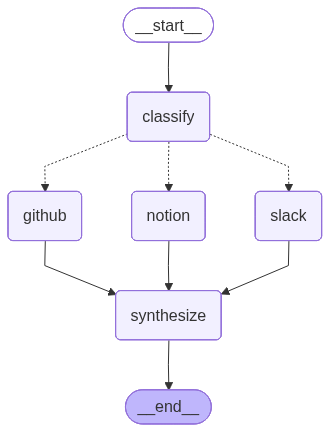

In [9]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(RouterState)

workflow.add_node("classify", classify_query)
workflow.add_node("github", query_github)
workflow.add_node("notion", query_notion)
workflow.add_node("slack", query_slack)
workflow.add_node("synthesize", synthesize_answer)

workflow.add_edge(START, "classify")
workflow.add_conditional_edges("classify", route_to_agents, ["github", "notion", "slack"])
workflow.add_edge("github", "synthesize")
workflow.add_edge("notion", "synthesize")
workflow.add_edge("slack", "synthesize")
workflow.add_edge("synthesize", END)

router_graph = workflow.compile()
router_graph

## 8. 라우터 실행

다양한 쿼리로 라우터를 테스트합니다.

In [10]:
# 쿼리 1: API 인증
query1 = "API 요청을 어떻게 인증하나요?"

print("=" * 80)
print(f"쿼리: {query1}")
print("=" * 80)

result1 = router_graph.invoke({
    "query": query1,
    "classifications": [],
    "results": [],
    "final_answer": ""
})

print("\n분류 결과:")
for cls in result1["classifications"]:
    print(f"  - {cls['source']}: {cls['query']}")

print("\n에이전트 결과:")
for r in result1["results"]:
    print(f"  [{r['source']}]: {r['result'][:100]}...")

print("\n최종 답변:")
print(result1["final_answer"])

쿼리: API 요청을 어떻게 인증하나요?

분류 결과:
  - github: API 요청 인증 방식은 코드베이스에서 어떻게 구현되어 있나요? 사용 중인 인증 메커니즘(예: API key, JWT, OAuth, 세션)과 요청 헤더/토큰 검증 로직, 관련 미들웨어나 설정 파일을 확인해 주세요.
  - notion: 팀 내부 문서에 정의된 API 요청 인증 정책이나 가이드가 있나요? 인증 방식, 토큰 발급/갱신 절차, 운영/개발 환경별 요구사항을 찾아주세요.

에이전트 결과:
  [github]: 요약 먼저 — 코드베이스는 src/auth.py에 중앙화된 인증 미들웨어를 두고 있으며, 현재 두 가지 인증 메커니즘을 지원합니다:

- API Key (헤더 기반)
- JWT (...
  [notion]: 있습니다 — 워크스페이스에서 "API 인증 가이드" 문서를 찾았습니다. 이 문서는 내부 API 요청 인증 관련한 정책·가이드(인증 방식, 토큰 발급/갱신 절차, 환경별 요구사항 등...

최종 답변:
요약
- 현재 코드베이스와 내부 가이드를 종합하면 API 요청은 주로 두 가지 방식으로 인증됩니다: 헤더 기반 API Key와 Authorization 헤더의 JWT(Bearer) 토큰. (추가로 조직 가이드에는 OAuth2 표준 플로우도 명시되어 있음)
- 코드 위치/구현은 src/auth.py에 중앙화된 인증 로직(미들웨어/데코레이터)이 있고, 환경변수(API_KEY, JWT_SECRET 등)를 비교/검증하는 방식입니다.
- 필요하면 src/auth.py의 정확한 코드 블록이나 가이드 문서에서 TTL·엔드포인트 같은 수치를 바로 발췌해 드릴 수 있습니다.

구체적 인증 흐름(개발자가 보는 관점)
1. 요청 수신 → 전역 미들웨어(app.before_request) 또는 엔드포인트 데코레이터(require_auth)에서 인증 시도
2. 헤더 검사 순서(일반적 구현)
   - X-API-Key 헤더가 있으면 API Key 경로로 검증
   - Authorization 헤더

## 9. 스트리밍 실행

각 단계를 스트리밍으로 확인합니다.

In [11]:
query2 = "OAuth 인증 플로우는 어떻게 작동하나요?"

print("=" * 80)
print(f"쿼리: {query2}")
print("=" * 80)

for step in router_graph.stream({
    "query": query2,
    "classifications": [],
    "results": [],
    "final_answer": ""
}, stream_mode="values"):
    if "classifications" in step and step["classifications"]:
        print("\n[분류 단계]")
        for cls in step["classifications"]:
            print(f"  → {cls['source']}: {cls['query']}")
    
    if "results" in step and step["results"]:
        print("\n[결과 수집 단계]")
        for r in step["results"]:
            print(f"  [{r['source']}]: {r['result'][:80]}...")
    
    if "final_answer" in step and step["final_answer"]:
        print("\n[최종 답변]")
        print(step["final_answer"])

쿼리: OAuth 인증 플로우는 어떻게 작동하나요?

[분류 단계]
  → github: 프로젝트에서 OAuth 인증 플로우가 어떻게 구현되어 있는지 확인해 주세요. 로그인/인가 요청부터 callback 처리, token exchange, refresh token 사용, scope 설정, 에러 처리까지 관련 코드와 API 구현 세부사항을 찾아보는 하위 질문입니다.
  → notion: 팀 내부 문서에서 OAuth 인증 플로우의 설계 의도, 지원하는 provider, 보안 정책, 환경별 설정 방법, 운영/배포 시 주의사항이 정리되어 있는지 확인해 주세요.
  → slack: 최근 팀 대화에서 OAuth 인증 플로우 관련 변경 사항, 이슈, 예외 케이스, 또는 현재 장애/질문이 논의된 내용이 있는지 찾아보는 하위 질문입니다.

[분류 단계]
  → github: 프로젝트에서 OAuth 인증 플로우가 어떻게 구현되어 있는지 확인해 주세요. 로그인/인가 요청부터 callback 처리, token exchange, refresh token 사용, scope 설정, 에러 처리까지 관련 코드와 API 구현 세부사항을 찾아보는 하위 질문입니다.
  → notion: 팀 내부 문서에서 OAuth 인증 플로우의 설계 의도, 지원하는 provider, 보안 정책, 환경별 설정 방법, 운영/배포 시 주의사항이 정리되어 있는지 확인해 주세요.
  → slack: 최근 팀 대화에서 OAuth 인증 플로우 관련 변경 사항, 이슈, 예외 케이스, 또는 현재 장애/질문이 논의된 내용이 있는지 찾아보는 하위 질문입니다.

[결과 수집 단계]
  [github]: 요청하신 내용(로그인/인가 요청 → callback 처리 → token 교환 → refresh token 사용 → scope 설정 → 에러 처리...
  [notion]: 확인해봤습니다. 현재 워크스페이스에서 찾은 관련 문서는 다음 한 건입니다.

- 문서: "API 인증 가이드"  
  - 요약: "단계별 인증 ...
  [slac

## 10. 실전 예제: 다양한 쿼리 패턴

In [12]:
queries = [
    "코드 리뷰 프로세스는 어떻게 되나요?",
    "새로운 기능 개발 가이드라인은?",
    "배포 절차는 어떻게 되나요?"
]

for query in queries:
    print("\n" + "=" * 80)
    print(f"쿼리: {query}")
    print("=" * 80)
    
    result = router_graph.invoke({
        "query": query,
        "classifications": [],
        "results": [],
        "final_answer": ""
    })
    
    print(f"\n관련 소스: {[cls['source'] for cls in result['classifications']]}")
    print(f"\n답변: {result['final_answer'][:200]}...")


쿼리: 코드 리뷰 프로세스는 어떻게 되나요?

관련 소스: ['notion', 'slack']

답변: 요약
- 코드 리뷰의 목적: 코드 품질·보안·지식공유·배포 안정성 확보.
- 권장 전체 흐름: PR 생성 → 자동 검사(CI/린트/보안) → 리뷰(1~2인) → 승인 조건 충족 시 머지(브랜치 보호) → 필요 시 배포/사후 리뷰.
- 기본 권장 값(조직별 조정 권장): 첫 응답 24시간, 승인자 1~2명, 승인 후 48시간 이내 머지 권장, 핫픽스 2시간 ...

쿼리: 새로운 기능 개발 가이드라인은?

관련 소스: ['notion', 'slack']

답변: 요청하신 원본 질문("새로운 기능 개발 가이드라인은?")에 대해, 제공된 Notion/Slack 검색 결과를 통합하여 포괄적이고 실무에 바로 적용 가능한 가이드라인을 정리했습니다. 아래 내용은 현재 확인된 조직 내 정보(발견된 항목·누락 항목)를 반영한 표준 프로세스 + 필수 정책·체크리스트 초안과, 다음에 취할 수 있는 구체적 액션 제안으로 구성되어 있습...

쿼리: 배포 절차는 어떻게 되나요?

관련 소스: ['notion', 'slack', 'github']

답변: 요약(결론 먼저)
- 현재 워크스페이스/레포지토리에서는 공식화된 배포 절차 문서나 자동화 설정을 찾지 못했습니다. Slack에서는 인증(Bearer token) 변경 논의가 있어 배포 시 호환성/롤아웃 고려가 필요합니다. 따라서 아래 권장 표준 배포 절차(사전 준비 → 승인 → 실행 → 검증 → 롤백)와 체크리스트, 자동화 도입 권장 사항을 따라 문서화·자...


## 주요 포인트 정리

1. **라우터 패턴**: 쿼리 분류 → 전문 에이전트로 라우팅 → 결과 통합
2. **병렬 처리**: 여러 에이전트를 동시에 호출하여 효율성 향상
3. **전문 에이전트**: 각 지식 소스별로 최적화된 에이전트
4. **결과 통합**: 여러 소스의 정보를 하나의 일관된 답변으로 통합
5. **확장성**: 새로운 지식 소스를 쉽게 추가 가능

**다음 단계**: 
- [340_Skills_Pattern.py](340_Skills_Pattern.py)에서 스킬 기반 패턴 학습
- [310_Subagents_Pattern.py](310_Subagents_Pattern.py)에서 하위 에이전트 패턴 비교